# 04 - Escalamiento y PCA

PCA se aplica sobre variables numéricas comparables luego de estandarizar. No se guardan columnas nuevas en el dataset procesado; la matriz escalada existe solo para este análisis.


In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

sns.set_theme(style="whitegrid")
ROOT = Path("..").resolve()
df = pd.read_csv(ROOT / "data" / "processed" / "streaming_users_processed.csv")
variables = ["age", "monthly_watch_time_mins", "customer_support_tickets"]
X = df[variables].copy()
X.head()


,age,monthly_watch_time_mins,customer_support_tickets
0,39,805.8,4
1,37,1173.4,2
2,28,401.0,0
3,43,62.4,0
4,51,477.8,1


## Escalamiento

Las variables tienen unidades distintas: edad en años, visualización en minutos y tickets como conteo. Se usa Z-score para que PCA no quede dominado por la variable de mayor magnitud.


In [2]:
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=variables)
X_scaled.describe().round(3)


,age,monthly_watch_time_mins,customer_support_tickets
count,8000.000,8000.000,8000.000
mean,0.000,-0.000,-0.000
std,1.000,1.000,1.000
min,-1.808,-1.699,-0.885
25%,-0.673,-0.642,-0.885
50%,-0.062,-0.064,0.186
75%,0.637,0.550,0.186
max,4.041,4.822,3.401


In [3]:
pca = PCA(n_components=3, random_state=42)
componentes = pca.fit_transform(X_scaled)
varianza = pd.DataFrame({
    "componente": ["PC1", "PC2", "PC3"],
    "varianza_explicada": pca.explained_variance_ratio_,
    "varianza_acumulada": np.cumsum(pca.explained_variance_ratio_)
})
varianza


,componente,varianza_explicada,varianza_acumulada
0,PC1,0.338017,0.338017
1,PC2,0.331281,0.669298
2,PC3,0.330702,1.000000


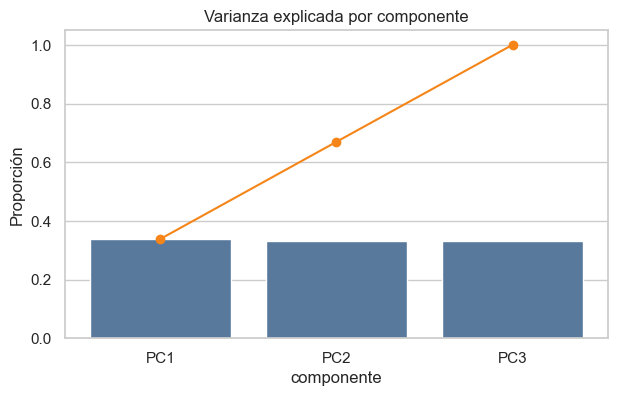

In [4]:
plt.figure(figsize=(7,4))
sns.barplot(data=varianza, x="componente", y="varianza_explicada", color="#4c78a8")
plt.plot(varianza["componente"], varianza["varianza_acumulada"], marker="o", color="#f58518")
plt.ylim(0, 1.05)
plt.title("Varianza explicada por componente")
plt.ylabel("Proporción")
plt.show()


In [5]:
loadings = pd.DataFrame(pca.components_.T, index=variables, columns=["PC1", "PC2", "PC3"])
loadings.round(3)


,PC1,PC2,PC3
age,0.599,-0.110,0.793
monthly_watch_time_mins,0.560,0.766,-0.317
customer_support_tickets,0.573,-0.634,-0.520


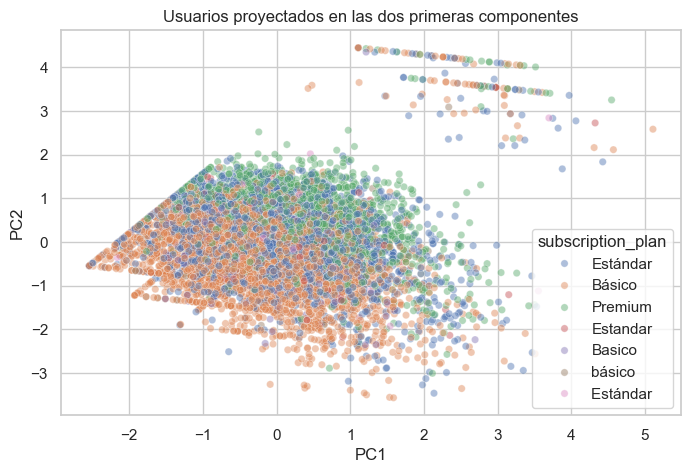

In [6]:
pc_df = pd.DataFrame(componentes[:, :2], columns=["PC1", "PC2"])
pc_df["subscription_plan"] = df["subscription_plan"]
plt.figure(figsize=(8,5))
sns.scatterplot(data=pc_df, x="PC1", y="PC2", hue="subscription_plan", alpha=0.45, s=28)
plt.title("Usuarios proyectados en las dos primeras componentes")
plt.show()


## Interpretación

La varianza explicada indica cuánta información resume cada componente. Las cargas (`loadings`) muestran qué variables empujan cada eje: si `monthly_watch_time_mins` pesa fuerte en PC1, esa componente resume intensidad de consumo; si `customer_support_tickets` pesa en otra, representa fricción o necesidad de asistencia. La proyección por plan permite observar si los planes forman grupos diferenciados en el espacio numérico estandarizado.
